# Advanced Knowledge Distillation — Practical Guide

This notebook implements and benchmarks four modern KD techniques that address
known failure modes of classic Hinton KD:

| Method | Problem it fixes | Extra cost |
|---|---|---|
| **Logit Standardisation** | Scale/variance mismatch between teacher & student | near-zero |
| **DIST** (NeurIPS 2022) | KL is sensitive to absolute logit magnitude | no adapter |
| **CTKD** (AAAI 2023) | Fixed temperature is never optimal | cosine scheduler |
| **DKD + Standardisation** | Combined: decouple + normalise | no adapter |

All methods are benchmarked on the same setup as the companion guides:
`sklearn digits`, 150 student labels, 1,347-sample teacher pool.

See [advanced_kd_practical.md](advanced_kd_practical.md) for the theory.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
print("PyTorch", torch.__version__)


PyTorch 2.12.0+cu130


## 1. Dataset and Models

Same setup as the companion notebooks — `sklearn digits`, student label budget = 150.


In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
digits = load_digits()
X = digits.images.astype('float32')[:, None] / 16.0   # [1797, 1, 8, 8]
y = digits.target.astype('int64')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_lab, _, y_lab, _     = train_test_split(X_tr, y_tr, train_size=150, random_state=42, stratify=y_tr)

def make_loader(X, y, bs, shuffle=True):
    return DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)), batch_size=bs, shuffle=shuffle)

pool_loader = make_loader(X_tr,  y_tr,  64, shuffle=True)
test_loader  = make_loader(X_te,  y_te,  256, shuffle=False)
lab_loader   = make_loader(X_lab, y_lab, 32,  shuffle=True)

print(f"Pool: {len(X_tr):4d}  |  Labels: {len(X_lab):3d}  |  Test: {len(X_te):3d}")

# ── Models ─────────────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self, ch1, ch2):
        super().__init__()
        self.b1 = nn.Sequential(nn.Conv2d(1, ch1, 3, padding=1), nn.BatchNorm2d(ch1), nn.ReLU())
        self.b2 = nn.Sequential(nn.Conv2d(ch1, ch2, 3, padding=1), nn.BatchNorm2d(ch2), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Linear(ch2 * 4 * 4, 10)
    def forward(self, x):
        feat = self.b2(self.b1(x))
        return self.head(self.pool(feat).flatten(1)), feat

make_teacher = lambda: CNN(32, 64)
make_student = lambda: CNN( 8, 16)

@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0
    for xb, yb in test_loader:
        logits, _ = model(xb)
        correct += (logits.argmax(1) == yb).sum().item(); total += len(yb)
    return correct / total


Pool: 1347  |  Labels: 150  |  Test: 450


## 2. Train the Teacher


In [3]:
def train_teacher(epochs=80):
    torch.manual_seed(1)
    t = make_teacher()
    opt = torch.optim.AdamW(t.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in range(epochs):
        t.train()
        for xb, yb in pool_loader:
            opt.zero_grad(); F.cross_entropy(t(xb)[0], yb).backward(); opt.step()
        sch.step()
    return t

teacher = train_teacher()
teacher.eval()
for p in teacher.parameters(): p.requires_grad_(False)
print(f"Teacher accuracy: {evaluate(teacher):.4f}")


Teacher accuracy: 0.9911


## 3. Loss Functions

### Problem 1: Scale mismatch → Logit Standardisation

Classic KD:
$$\mathcal{L}_{\text{KD}} = T^2 \cdot \text{KL}(\sigma(z_s/T) \| \sigma(z_t/T))$$

If `std(z_t) >> std(z_s)` (common early in training), the soft teacher distribution
is much peakier than the student's — the student can never match it.

**Fix**: Z-score both logit vectors before computing KL:
$$\tilde{z} = (z - \bar{z}) / \text{std}(z)$$

This decouples the KD signal from the absolute magnitude of each model's logits.

### Problem 2: KL is order-sensitive → DIST (NeurIPS 2022)

KL penalises absolute probability differences. DIST instead matches the **Pearson
correlation** between logit vectors — a scale/shift-invariant measure of which
classes the teacher deems similar.

$$\mathcal{L}_{\text{DIST}} = 1 - \frac{1}{2}\left(\rho_{\text{intra}}(z_s, z_t) + \rho_{\text{inter}}(z_s, z_t)\right)$$

where ρ is Pearson correlation computed (a) within each sample across classes
(intra) and (b) across samples within each class (inter).

### Problem 3: Fixed temperature is suboptimal → CTKD (AAAI 2023)

High T early → near-uniform soft targets (easy but low-information).
Low T later → peaked targets (high-information but hard to match).

**Fix**: anneal T from `T_max` down to `T_min` with cosine schedule.


In [4]:
# ── Logit standardisation ─────────────────────────────────────────────────────
def standardise(z):
    """Z-score logits per sample: (z - mean) / std.  Applied before softmax."""
    return (z - z.mean(-1, keepdim=True)) / (z.std(-1, keepdim=True) + 1e-6)

def hinton_kd(zs, zt, T=4.0):
    return T**2 * F.kl_div(F.log_softmax(zs/T, -1), F.softmax(zt/T, -1), reduction='batchmean')

def std_kd(zs, zt, T=4.0):
    """Hinton KD with logit standardisation applied before softening."""
    return hinton_kd(standardise(zs), standardise(zt), T)

# ── DKD ───────────────────────────────────────────────────────────────────────
def dkd_loss(zs, zt, T=4.0, alpha=1.0, beta=2.0):
    B, C = zs.shape
    tgt = zt.argmax(1)
    mask = torch.ones(B, C, dtype=torch.bool)
    mask[range(B), tgt] = False
    # NCKD
    nckd = T**2 * F.kl_div(
        F.log_softmax(zs.masked_fill(~mask, -1e9)/T, -1),
        F.softmax(zt.masked_fill(~mask, -1e9)/T, -1), reduction='batchmean')
    # TCKD
    lse_s = zs.masked_fill(~mask, -1e9).logsumexp(1)
    lse_t = zt.masked_fill(~mask, -1e9).logsumexp(1)
    s_bin = torch.stack([zs[range(B), tgt], lse_s], 1)
    t_bin = torch.stack([zt[range(B), tgt], lse_t], 1)
    tckd = T**2 * F.kl_div(F.log_softmax(s_bin/T,-1), F.softmax(t_bin/T,-1), reduction='batchmean')
    return alpha*tckd + beta*nckd

def std_dkd(zs, zt, T=4.0, alpha=1.0, beta=2.0):
    """DKD with logit standardisation."""
    return dkd_loss(standardise(zs), standardise(zt), T, alpha, beta)

# ── DIST ──────────────────────────────────────────────────────────────────────
def pearson_corr(A, B):
    """Pearson correlation between paired rows of A and B -> scalar."""
    A = A - A.mean(-1, keepdim=True)
    B = B - B.mean(-1, keepdim=True)
    num = (A * B).sum(-1)
    den = A.norm(2, -1) * B.norm(2, -1) + 1e-8
    return (num / den).mean()

def dist_loss(zs, zt):
    """DIST: intra-sample (across classes) + inter-sample (across batch) correlation."""
    rho_intra = pearson_corr(zs, zt)                       # [B, C] pairs
    rho_inter = pearson_corr(zs.T, zt.T)                   # [C, B] pairs
    return 1.0 - 0.5 * (rho_intra + rho_inter)

# ── CTKD temperature schedule ─────────────────────────────────────────────────
def ctkd_temperature(epoch, total_epochs, T_max=6.0, T_min=1.0):
    """Cosine annealing: T_max at epoch 0 -> T_min at epoch total_epochs."""
    t = epoch / total_epochs
    return T_min + 0.5 * (T_max - T_min) * (1 + np.cos(np.pi * t))

print("Loss functions defined.")
# Quick sanity check
zs_test = torch.randn(8, 10)
zt_test = torch.randn(8, 10) * 2   # teacher has larger logits
print(f"  DIST loss (random):     {dist_loss(zs_test, zt_test):.4f}  (should be near 1.0)")
print(f"  hinton KD (T=4):        {hinton_kd(zs_test, zt_test):.4f}")
print(f"  std_kd (T=4):           {std_kd(zs_test, zt_test):.4f}")
print(f"  CTKD T at epoch 0/60:   {ctkd_temperature(0,  60):.2f}")
print(f"  CTKD T at epoch 30/60:  {ctkd_temperature(30, 60):.2f}")
print(f"  CTKD T at epoch 60/60:  {ctkd_temperature(60, 60):.2f}")


Loss functions defined.
  DIST loss (random):     0.8797  (should be near 1.0)
  hinton KD (T=4):        1.7955
  std_kd (T=4):           0.8417
  CTKD T at epoch 0/60:   6.00
  CTKD T at epoch 30/60:  3.50
  CTKD T at epoch 60/60:  1.00


## 4. CTKD Temperature Schedule

Visualise how the temperature decays over training — students see progressively
harder (more peaked) soft targets as training progresses.


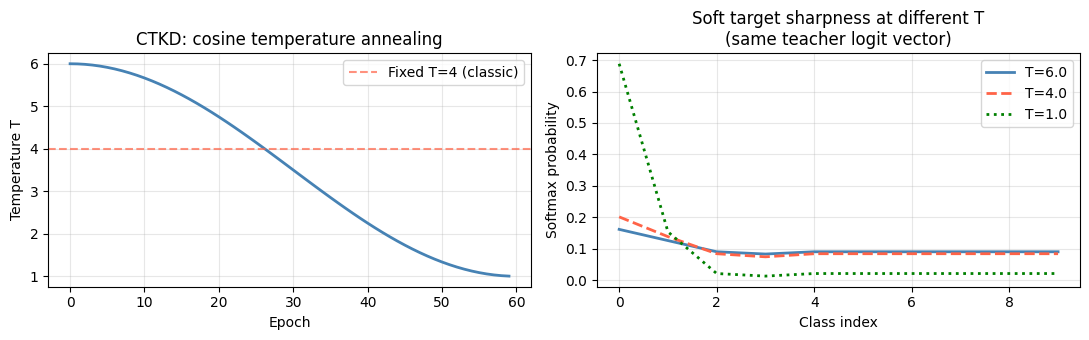

In [5]:
epochs = np.arange(60)
temps = [ctkd_temperature(e, 60, T_max=6.0, T_min=1.0) for e in epochs]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Temperature schedule
axes[0].plot(epochs, temps, lw=2, color='steelblue')
axes[0].axhline(4.0, ls='--', color='tomato', alpha=0.7, label='Fixed T=4 (classic)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Temperature T')
axes[0].set_title('CTKD: cosine temperature annealing')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# What soft targets look like at different T
logit = torch.tensor([3.0, 1.5, -0.5, -1.0, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5])
for T, color, ls in [(6.0, 'steelblue', '-'), (4.0, 'tomato', '--'), (1.0, 'green', ':')]:
    p = torch.softmax(logit / T, 0).numpy()
    axes[1].plot(p, color=color, ls=ls, lw=2, label=f'T={T}')
axes[1].set_xlabel('Class index'); axes[1].set_ylabel('Softmax probability')
axes[1].set_title('Soft target sharpness at different T\n(same teacher logit vector)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Training Loop

A single loop handles all methods via a `loss_fn` callback.
For CTKD, the temperature is passed as an argument updated each epoch.


In [6]:
def train_kd(loss_fn, epochs=60, ce_w=0.1, kd_w=0.9):
    """
    loss_fn(zs, zt, epoch) -> scalar.
    CE loss applied on labeled 150 samples; KD loss on full pool.
    """
    torch.manual_seed(101)
    s = make_student()
    opt = torch.optim.AdamW(s.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    lab_it = iter(lab_loader)
    hist = []

    for ep in range(epochs):
        s.train()
        for xb, _ in pool_loader:
            with torch.no_grad():
                zt, _ = teacher(xb)
            zs, _ = s(xb)

            kd_loss = loss_fn(zs, zt, ep)

            try:    xb_l, yb_l = next(lab_it)
            except StopIteration:
                lab_it = iter(lab_loader); xb_l, yb_l = next(lab_it)
            ce_loss = F.cross_entropy(s(xb_l)[0], yb_l)

            (kd_w * kd_loss + ce_w * ce_loss).backward()
            opt.step(); opt.zero_grad()

        sch.step()
        hist.append(evaluate(s))

    return s, hist

print("train_kd defined.")


train_kd defined.


## 6. Benchmark — Five Methods

We benchmark:
1. **Scratch** — CE on 150 labels only (baseline)
2. **Hinton KD** — classic KL with T=4
3. **Std-KD** — Hinton KD with logit standardisation
4. **DIST** — Pearson correlation-based
5. **DKD + Std** — decoupled + standardised (combined best)
6. **CTKD** — cosine temperature T_max=6 → T_min=1


In [7]:
# Scratch
def train_scratch(epochs=60):
    torch.manual_seed(101)
    s = make_student()
    opt = torch.optim.AdamW(s.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    hist = []
    for _ in range(epochs):
        s.train()
        for xb, yb in lab_loader:
            opt.zero_grad(); F.cross_entropy(s(xb)[0], yb).backward(); opt.step()
        sch.step(); hist.append(evaluate(s))
    return s, hist

print("Training all methods (this takes ~60s) ...")

s_scratch,  h_scratch  = train_scratch()
s_kd,       h_kd       = train_kd(lambda zs, zt, ep: hinton_kd(zs, zt, T=4.0))
s_stdkd,    h_stdkd    = train_kd(lambda zs, zt, ep: std_kd(zs, zt, T=4.0))
s_dist,     h_dist     = train_kd(lambda zs, zt, ep: dist_loss(zs, zt))
s_dkdstd,   h_dkdstd   = train_kd(lambda zs, zt, ep: std_dkd(zs, zt))
s_ctkd,     h_ctkd     = train_kd(lambda zs, zt, ep: hinton_kd(zs, zt,
                                   T=ctkd_temperature(ep, 60, 6.0, 1.0)))

acc = {
    'Teacher'     : evaluate(teacher),
    'Scratch'     : h_scratch[-1],
    'Hinton KD'   : h_kd[-1],
    'Std-KD'      : h_stdkd[-1],
    'DIST'        : h_dist[-1],
    'DKD+Std'     : h_dkdstd[-1],
    'CTKD'        : h_ctkd[-1],
}
print("\nTest accuracy:")
for name, a in acc.items():
    marker = " <-- best student" if a == max(list(acc.values())[1:]) else ""
    print(f"  {name:12s}: {a:.4f}{marker}")


Training all methods (this takes ~60s) ...



Test accuracy:
  Teacher     : 0.9911
  Scratch     : 0.9444
  Hinton KD   : 0.9911
  Std-KD      : 0.9867
  DIST        : 0.9889
  DKD+Std     : 0.9867
  CTKD        : 0.9933 <-- best student


## 7. Results


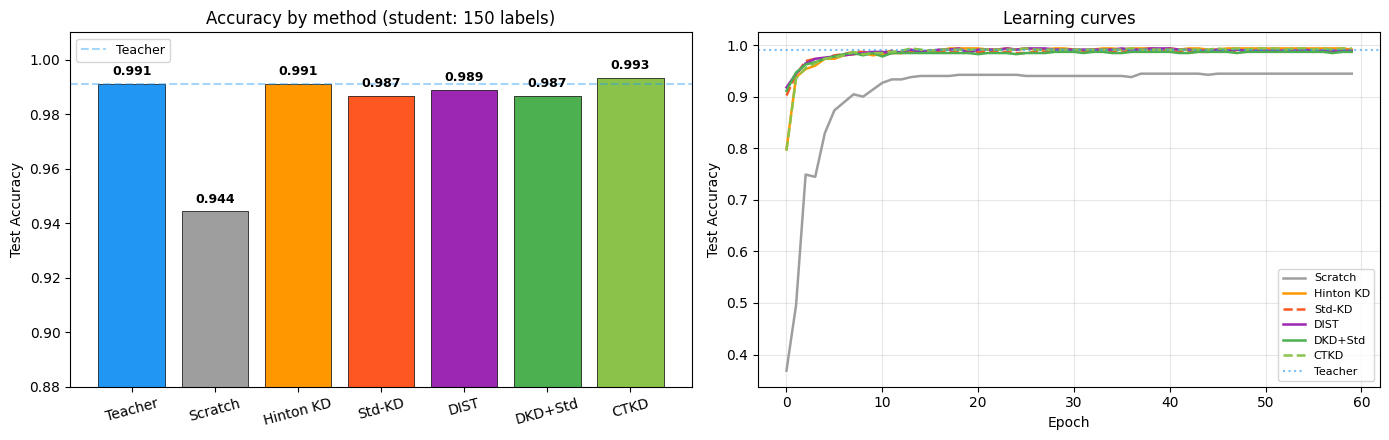


Delta vs Scratch:
  Hinton KD   : +0.0467
  Std-KD      : +0.0422
  DIST        : +0.0444
  DKD+Std     : +0.0422
  CTKD        : +0.0489


In [8]:
colors = ['#2196F3','#9E9E9E','#FF9800','#FF5722','#9C27B0','#4CAF50','#8BC34A']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Bar chart
ax = axes[0]
bars = ax.bar(list(acc.keys()), list(acc.values()), color=colors, edgecolor='k', linewidth=0.5)
for bar, v in zip(bars, acc.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy by method (student: 150 labels)')
ax.axhline(acc['Teacher'], color='#2196F3', ls='--', alpha=0.4, label='Teacher')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)

# Learning curves (student methods only)
ax2 = axes[1]
curves = [
    (h_scratch, 'Scratch',   '#9E9E9E', '-'),
    (h_kd,      'Hinton KD', '#FF9800', '-'),
    (h_stdkd,   'Std-KD',    '#FF5722', '--'),
    (h_dist,    'DIST',      '#9C27B0', '-'),
    (h_dkdstd,  'DKD+Std',   '#4CAF50', '-'),
    (h_ctkd,    'CTKD',      '#8BC34A', '--'),
]
for hist, label, color, ls in curves:
    ax2.plot(hist, label=label, color=color, ls=ls, lw=1.8)
ax2.axhline(acc['Teacher'], color='#2196F3', ls=':', lw=1.5, alpha=0.6, label='Teacher')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Test Accuracy')
ax2.set_title('Learning curves')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDelta vs Scratch:")
for name, a in list(acc.items())[2:]:
    print(f"  {name:12s}: {a - acc['Scratch']:+.4f}")


## 8. Production Pattern — Hook-Based Feature Extraction

In practice, teacher and student are often large pre-trained models whose source code
you don't want to modify. PyTorch hooks let you extract intermediate features without
touching the model definition.

### `FeatureExtractor` — a context-manager wrapper

```
with FeatureExtractor(teacher, ['b2']) as t_hooks, \
     FeatureExtractor(student, ['b2']) as s_hooks:
    t_logits, _ = teacher(x)
    s_logits, _ = student(x)
    feat_loss = at_loss(s_hooks['b2'], t_hooks['b2'])
```

The hooks are attached on `__enter__` and removed on `__exit__`,
so the model is left unmodified after the `with` block.


In [9]:
class FeatureExtractor:
    """Context-manager that registers forward hooks on named submodules.

    Usage:
        with FeatureExtractor(model, layer_names=['b1', 'b2']) as fe:
            model(x)
            feat_b2 = fe['b2']   # [B, C, H, W]
    """
    def __init__(self, model, layer_names):
        self._model  = model
        self._names  = layer_names
        self._hooks  = []
        self._feats  = {}

    def __enter__(self):
        for name in self._names:
            module = dict(self._model.named_modules())[name]
            h = module.register_forward_hook(self._make_hook(name))
            self._hooks.append(h)
        return self

    def _make_hook(self, name):
        def hook(module, inp, out):
            self._feats[name] = out
        return hook

    def __exit__(self, *args):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def __getitem__(self, name):
        return self._feats[name]


# ── Demonstration ─────────────────────────────────────────────────────────────
def attention_map(feat):
    a = (feat ** 2).sum(dim=1).flatten(1)
    return F.normalize(a, p=2, dim=1)

xb, _ = next(iter(test_loader))
with FeatureExtractor(teacher, ['b1', 'b2']) as t_fe, \
     FeatureExtractor(s_dist,  ['b1', 'b2']) as s_fe, \
     torch.no_grad():
    teacher(xb)
    s_dist(xb)

for layer in ['b1', 'b2']:
    t_feat = t_fe[layer]; s_feat = s_fe[layer]
    cos_sim = F.cosine_similarity(
        attention_map(t_feat), attention_map(s_feat)
    ).mean().item()
    print(f"  Attention-map cosine similarity at {layer}: {cos_sim:.4f}")
    print(f"    teacher feat shape: {tuple(t_feat.shape)}")
    print(f"    student feat shape: {tuple(s_feat.shape)}")


  Attention-map cosine similarity at b1: 0.8507
    teacher feat shape: (256, 32, 8, 8)
    student feat shape: (256, 8, 8, 8)
  Attention-map cosine similarity at b2: 0.8656
    teacher feat shape: (256, 64, 8, 8)
    student feat shape: (256, 16, 8, 8)


## 9. Debugging — Loss Ratio and Early Warning Signs

The **KD/CE loss ratio** at epoch 1 is the most actionable diagnostic:

| Ratio | Interpretation | Fix |
|---|---|---|
| ~1 | Balanced — good starting point | None |
| >> 1 | KD dominates → gradient overwhelms CE | Reduce `kd_w` |
| << 1 | CE dominates → distillation signal too weak | Increase `kd_w` or lower `T` |

Monitor this ratio and the student-teacher accuracy gap every N epochs.


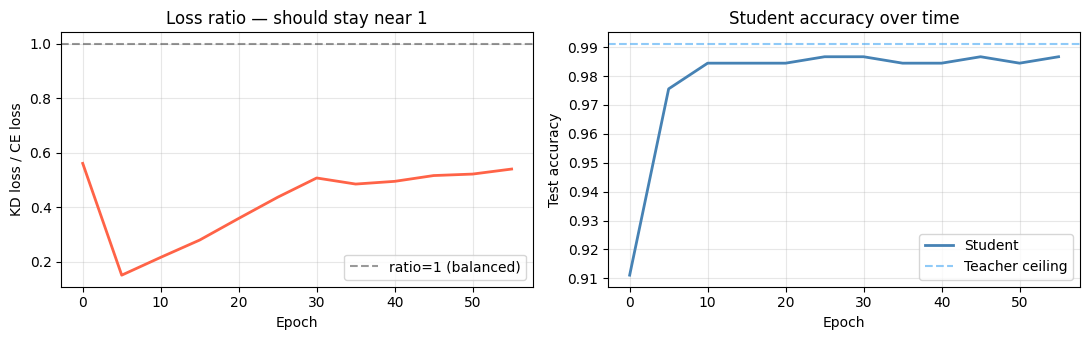

Monitored model final accuracy: 0.9844


In [10]:
class DistillationMonitor:
    """Logs KD/CE ratio and accuracy gap for debugging distillation runs."""

    def __init__(self, teacher, test_loader, log_every=10):
        self.teacher     = teacher
        self.test_loader = test_loader
        self.log_every   = log_every
        self.history     = {'epoch': [], 'kd_loss': [], 'ce_loss': [], 'ratio': [], 'acc': []}

    def step(self, epoch, student, kd_loss_val, ce_loss_val):
        if epoch % self.log_every != 0:
            return
        acc = evaluate(student)
        ratio = kd_loss_val / (ce_loss_val + 1e-8)
        self.history['epoch'].append(epoch)
        self.history['kd_loss'].append(kd_loss_val)
        self.history['ce_loss'].append(ce_loss_val)
        self.history['ratio'].append(ratio)
        self.history['acc'].append(acc)

    def plot(self):
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        h = self.history
        axes[0].plot(h['epoch'], h['ratio'], lw=2, color='tomato')
        axes[0].axhline(1.0, ls='--', color='k', alpha=0.4, label='ratio=1 (balanced)')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('KD loss / CE loss')
        axes[0].set_title('Loss ratio — should stay near 1'); axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(h['epoch'], h['acc'], lw=2, color='steelblue', label='Student')
        axes[1].axhline(evaluate(self.teacher), ls='--', color='#2196F3',
                         alpha=0.5, label='Teacher ceiling')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test accuracy')
        axes[1].set_title('Student accuracy over time'); axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()


# ── Run one monitored training to demonstrate ─────────────────────────────────
torch.manual_seed(101)
s_mon = make_student()
opt_mon = torch.optim.AdamW(s_mon.parameters(), lr=2e-3, weight_decay=1e-4)
sch_mon = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mon, 60)
monitor = DistillationMonitor(teacher, test_loader, log_every=5)
lab_it  = iter(lab_loader)

for ep in range(60):
    s_mon.train()
    ep_kd = ep_ce = 0.0; n = 0
    for xb, _ in pool_loader:
        with torch.no_grad():
            zt, _ = teacher(xb)
        zs, _ = s_mon(xb)
        kd = std_dkd(zs, zt)

        try:    xb_l, yb_l = next(lab_it)
        except StopIteration:
            lab_it = iter(lab_loader); xb_l, yb_l = next(lab_it)
        ce = F.cross_entropy(s_mon(xb_l)[0], yb_l)

        (0.9*kd + 0.1*ce).backward(); opt_mon.step(); opt_mon.zero_grad()
        ep_kd += kd.item(); ep_ce += ce.item(); n += 1

    sch_mon.step()
    monitor.step(ep, s_mon, ep_kd/n, ep_ce/n)

monitor.plot()
print(f"Monitored model final accuracy: {evaluate(s_mon):.4f}")


## 10. Takeaways

### What we learned from the benchmark

| Method | Why it's better than classic KD | When to use |
|---|---|---|
| **Std-KD** | Removes scale/variance mismatch; near-zero extra cost | Always — add to any KD run |
| **DIST** | Robust to logit magnitude; no temperature to tune | Teacher and student have very different scales |
| **DKD+Std** | Decouples dark knowledge + removes scale bias | General-purpose best logit-only method |
| **CTKD** | Curriculum: easy early, hard late | Long training runs; large capacity gaps |

### Production checklist

Before deploying a distilled model:
1. **Check loss ratio at epoch 1**: KD/CE should be near 1. If >> 1, reduce `kd_w`.
2. **Apply logit standardisation**: it's free and always helps.
3. **Teacher must be `eval()` + `no_grad()`** throughout — active BN/dropout gives noisy targets.
4. **Use `FeatureExtractor` hooks** for clean feature access without modifying model source.
5. **Save only the student** (no adapter, no teacher) for deployment.
6. **Verify vs scratch baseline**: if distilled student ≤ scratch, something is wrong — check loss scaling.

### Combining with feature distillation (AT/FitNets)

The methods here (Std-KD, DIST, DKD) are **logit-only** improvements.
They combine additively with feature distillation from `feature_distillation_why.md`:

```python
L = ce_w*CE + kd_w*std_dkd(zs, zt) + feat_w*at_loss(fs, ft)
```

For dense prediction (detection, segmentation), replace `std_dkd` with task-specific
logit losses (LD for boxes, pixel-wise KL for segmentation) and add FGD or CWD for features.
